# 05 — Modelo XGBoost

**TFM — Valoración Inmobiliaria Masiva: SLX vs Machine Learning**

---

### Contenido
1. Carga de datos (igual que notebook 04)
2. Modelo baseline: `XGBRegressor(n_estimators=100, random_state=42, eval_metric='rmse')`
3. Cross-validation 5-fold
4. Hyperparameter tuning con `RandomizedSearchCV` (n_iter=20):
   - `learning_rate`: [0.01, 0.05, 0.1, 0.3]
   - `n_estimators`: [100, 300, 500]
   - `max_depth`: [3, 5, 7, 9]
   - `subsample`: [0.7, 0.8, 1.0]
   - `colsample_bytree`: [0.7, 0.8, 1.0]
5. Entrenamiento del mejor modelo
6. Evaluación en test: RMSE, MAE, R² (escala log y original)
7. Feature importance nativa de XGBoost
8. Residuos + Índice de Moran I
9. Guardado del modelo y métricas en `outputs/metrics/xgb_metrics.json`

---
## Setup e imports

In [1]:
import sys
import os
import warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV, cross_val_score, KFold
from sklearn.metrics import r2_score

from utils import set_plot_style, evaluate_model, save_metrics, compute_moran_i

set_plot_style()

PROCESSED = '../data/processed/'
FIGURES   = '../outputs/figures/'
METRICS   = '../outputs/metrics/'
MODELS    = '../outputs/models/'
for d in [FIGURES, METRICS, MODELS]:
    os.makedirs(d, exist_ok=True)

SEED = 42
np.random.seed(SEED)

print('Entorno listo.')
print(f'Semilla de reproducibilidad: {SEED}')

Entorno listo.
Semilla de reproducibilidad: 42


---
## 1. Carga de datos

Cargamos los mismos ficheros que el notebook 04 (Random Forest):
- **`X_train_spatial` / `X_test_spatial`**: 30 features = 18 originales + 12 retardos espaciales KNN (k=15)
- **`X_train_orig` / `X_test_orig`**: solo las 18 features originales (para el baseline)
- **`y_train` / `y_test`**: target `log(price)` en escala logarítmica
- **`coords_test`**: coordenadas lat/long del conjunto de test (para Moran's I)

In [2]:
X_train_spatial = pd.read_csv(PROCESSED + 'X_train_spatial.csv')
X_test_spatial  = pd.read_csv(PROCESSED + 'X_test_spatial.csv')
X_train_orig    = pd.read_csv(PROCESSED + 'X_train.csv')
X_test_orig     = pd.read_csv(PROCESSED + 'X_test.csv')
y_train         = pd.read_csv(PROCESSED + 'y_train.csv').squeeze()
y_test          = pd.read_csv(PROCESSED + 'y_test.csv').squeeze()
coords_test     = pd.read_csv(PROCESSED + 'coords_test.csv').values

lag_cols  = [c for c in X_train_spatial.columns if c.startswith('lag_')]
orig_cols = [c for c in X_train_spatial.columns if not c.startswith('lag_')]

print(f'X_train_spatial : {X_train_spatial.shape}')
print(f'X_test_spatial  : {X_test_spatial.shape}')
print(f'y_train         : {y_train.shape}  |  rango: [{y_train.min():.2f}, {y_train.max():.2f}]')
print(f'y_test          : {y_test.shape}')
print(f'coords_test     : {coords_test.shape}')
print(f'\nFeatures originales ({len(orig_cols)}): {orig_cols}')
print(f'\nFeatures lag        ({len(lag_cols)}):  {lag_cols}')

X_train_spatial : (17289, 30)
X_test_spatial  : (4323, 30)
y_train         : (17289,)  |  rango: [11.23, 15.86]
y_test          : (4323,)
coords_test     : (4323, 2)

Features originales (18): ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15', 'sale_month', 'house_age', 'renovated']

Features lag        (12):  ['lag_bedrooms_k15', 'lag_bathrooms_k15', 'lag_sqft_living_k15', 'lag_sqft_lot_k15', 'lag_floors_k15', 'lag_waterfront_k15', 'lag_view_k15', 'lag_condition_k15', 'lag_grade_k15', 'lag_sqft_above_k15', 'lag_house_age_k15', 'lag_renovated_k15']


---
## 2. XGBoost Baseline (sin features espaciales)

El **baseline** entrena sobre las **18 features originales** con los parámetros por defecto del notebook.  
Su función es ser el punto de referencia mínimo: mide el valor *antes* de introducir la información geográfica.

> **Nota sobre `eval_metric='rmse'`**: en la API sklearn de XGBoost este parámetro solo actúa cuando  
> se pasa un `eval_set` en el `fit()`. Aquí lo incluimos para consistencia con la configuración  
> especificada en el notebook, pero el entrenamiento con sklearn no lo usa activamente.

In [3]:
xgb_baseline = XGBRegressor(
    n_estimators=100,
    random_state=SEED,
    eval_metric='rmse',
    verbosity=0
)
xgb_baseline.fit(X_train_orig, y_train)

y_pred_baseline = xgb_baseline.predict(X_test_orig)
metrics_baseline = evaluate_model(y_test.values, y_pred_baseline, 'XGB Baseline (sin espaciales)')


  XGB Baseline (sin espaciales)
  RMSE (log):    0.1665
  MAE  (log):    0.1198
  R²:            0.9030
  RMSE (€/$):    127,298
  MAE  (€/$):    67,986
  MAPE (%):      12.16%



---
## 3. XGBoost con features espaciales (pre-tuning)

Mismo modelo baseline pero ahora alimentado con las **30 features** (18 originales + 12 retardos KNN).  
Esta celda aísla el efecto de añadir información espacial *antes* de optimizar hiperparámetros.

A diferencia del modelo SLX (donde los retardos capturan efectos de vecindad de forma explícita  
e interpretable), aquí XGBoost los usa como cualquier otra feature: aprende automáticamente  
qué combinaciones no lineales de retardos predicen mejor el precio.

In [4]:
xgb_spatial = XGBRegressor(
    n_estimators=100,
    random_state=SEED,
    eval_metric='rmse',
    verbosity=0
)
xgb_spatial.fit(X_train_spatial, y_train)

y_pred_spatial = xgb_spatial.predict(X_test_spatial)
metrics_spatial = evaluate_model(y_test.values, y_pred_spatial, 'XGB Espacial (pre-tuning)')


  XGB Espacial (pre-tuning)
  RMSE (log):    0.1682
  MAE  (log):    0.1206
  R²:            0.9011
  RMSE (€/$):    129,940
  MAE  (€/$):    68,627
  MAPE (%):      12.22%



---
## 4. Cross-validation 5-fold

Estimamos el **error de generalización** del modelo espacial pre-tuning con validación cruzada.

El CV nos da dos cosas importantes:
1. **Estimación robusta del RMSE**: media sobre 5 folds distintos reduce el ruido de un único split
2. **Detección de overfitting anticipada**: si CV-RMSE >> test-RMSE del modelo final, el tuning habría memorizado el train

Usamos `KFold` con `shuffle=True` para evitar efectos de ordenación temporal en el dataset.

In [5]:
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

cv_scores = cross_val_score(
    xgb_spatial,
    X_train_spatial, y_train,
    cv=kf,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
cv_rmse = -cv_scores

print(f'Cross-validation 5-fold — XGB Espacial (pre-tuning):')
print(f'  RMSE por fold : {[f"{v:.4f}" for v in cv_rmse]}')
print(f'  RMSE medio    : {cv_rmse.mean():.4f}')
print(f'  RMSE std      : {cv_rmse.std():.4f}')
print(f'\n  Intervalo de confianza aprox. (±1 std): [{cv_rmse.mean()-cv_rmse.std():.4f}, {cv_rmse.mean()+cv_rmse.std():.4f}]')

Cross-validation 5-fold — XGB Espacial (pre-tuning):
  RMSE por fold : ['0.1705', '0.1713', '0.1756', '0.1714', '0.1689']
  RMSE medio    : 0.1715
  RMSE std      : 0.0022

  Intervalo de confianza aprox. (±1 std): [0.1693, 0.1737]


---
## 5. Hyperparameter Tuning con RandomizedSearchCV

### ¿Qué hace RandomizedSearchCV?
En lugar de probar todas las combinaciones posibles (GridSearch = 4×3×4×3×3 = **432 modelos**),  
muestrea aleatoriamente **20 combinaciones** del espacio de hiperparámetros y evalúa cada una  
con 5-fold CV. Es el balance óptimo entre exploración y coste computacional.

### ¿Qué controla cada hiperparámetro?

| Parámetro | Efecto | Rango explorado |
|-----------|--------|----------------|
| `learning_rate` | Peso de cada árbol en el ensemble. Bajo = más robusto, necesita más árboles | [0.01, 0.05, 0.1, 0.3] |
| `n_estimators` | Nº de árboles secuenciales | [100, 300, 500] |
| `max_depth` | Profundidad máxima por árbol. Mayor = más interacciones, más riesgo de overfit | [3, 5, 7, 9] |
| `subsample` | Fracción de filas usada por árbol (estocasticidad) | [0.7, 0.8, 1.0] |
| `colsample_bytree` | Fracción de features por árbol (como `max_features` en RF) | [0.7, 0.8, 1.0] |

> **Regla práctica**: `learning_rate` bajo + muchos `n_estimators` suele dar mejores resultados  
> pero es más lento. Con `learning_rate=0.01` y `n_estimators=500` el modelo hace 500 correcciones  
> pequeñas → muy preciso pero costoso.

In [6]:
param_dist = {
    'learning_rate':    [0.01, 0.05, 0.1, 0.3],
    'n_estimators':     [100, 300, 500],
    'max_depth':        [3, 5, 7, 9],
    'subsample':        [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
}

search = RandomizedSearchCV(
    XGBRegressor(random_state=SEED, eval_metric='rmse', verbosity=0),
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='neg_root_mean_squared_error',
    random_state=SEED,
    n_jobs=-1,
    verbose=1
)
search.fit(X_train_spatial, y_train)

print(f'\nMejores parámetros encontrados:')
for k, v in search.best_params_.items():
    print(f'  {k:20s}: {v}')
print(f'\nMejor CV RMSE (log): {-search.best_score_:.4f}')

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Mejores parámetros encontrados:
  subsample           : 0.7
  n_estimators        : 500
  max_depth           : 5
  learning_rate       : 0.05
  colsample_bytree    : 0.8

Mejor CV RMSE (log): 0.1609


---
## 6. Modelo final — entrenamiento con los mejores parámetros

Reentrenamos con los mejores hiperparámetros encontrados sobre **todos los datos de train**  
(sin partición de validación interna). Esto maximiza la información disponible para el modelo definitivo.

El `search.best_estimator_` ya está reentrenado en todo el train por defecto en sklearn  
(`refit=True`), pero lo instanciamos explícitamente para mayor claridad y control.

In [7]:
xgb_final = XGBRegressor(
    **search.best_params_,
    random_state=SEED,
    eval_metric='rmse',
    verbosity=0
)
xgb_final.fit(X_train_spatial, y_train)

print('Modelo XGBoost final entrenado.')
print(f'Parámetros: {search.best_params_}')

Modelo XGBoost final entrenado.
Parámetros: {'subsample': 0.7, 'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 0.8}


---
## 7. Evaluación en test

Evaluamos los tres modelos sobre el conjunto de test (**nunca visto** durante el entrenamiento ni el tuning).

Las métricas se calculan en dos escalas:
- **Escala log**: RMSE/MAE sobre `log(price)` — unidad comparable entre modelos
- **Escala original (dólares)**: retransformación con `exp()` — interpretable para el negocio
- **MAPE**: error porcentual medio — la métrica más usada en tasación inmobiliaria

In [8]:
y_pred_final = xgb_final.predict(X_test_spatial)
metrics_final = evaluate_model(y_test.values, y_pred_final, 'XGB Final (espacial + tuning)')

# Tabla comparativa de los tres modelos
print('\n=== TABLA COMPARATIVA ===')
comparativa = pd.DataFrame([metrics_baseline, metrics_spatial, metrics_final]).set_index('modelo')
display(comparativa)


  XGB Final (espacial + tuning)
  RMSE (log):    0.1599
  MAE  (log):    0.1144
  R²:            0.9106
  RMSE (€/$):    116,015
  MAE  (€/$):    64,031
  MAPE (%):      11.60%


=== TABLA COMPARATIVA ===


,RMSE_log,MAE_log,R2,RMSE_orig,MAE_orig,MAPE_orig
modelo,,,,,,
XGB Baseline (sin espaciales),0.166537,0.119783,0.902989,127297.96,67986.49,0.1216
XGB Espacial (pre-tuning),0.168188,0.120647,0.901056,129940.36,68627.30,0.1222
XGB Final (espacial + tuning),0.159872,0.114365,0.910599,116015.02,64031.23,0.1160


---
## 8. Feature Importance

XGBoost dispone de **múltiples métricas de importancia**. La API de sklearn expone `feature_importances_`  
que corresponde a la importancia por **ganancia** (*gain*): reducción media de la pérdida (MSE) aportada  
por cada feature en todos los splits donde aparece.

Esto es más informativo que la importancia por **frecuencia** (*weight*), que solo cuenta cuántas veces  
se usa una feature como nodo de split sin medir su impacto real en la pérdida.

Las barras se colorean para distinguir:
- **Azul** (`steelblue`): retardos espaciales KNN — información de vecindad
- **Coral**: features originales de la vivienda — características físicas

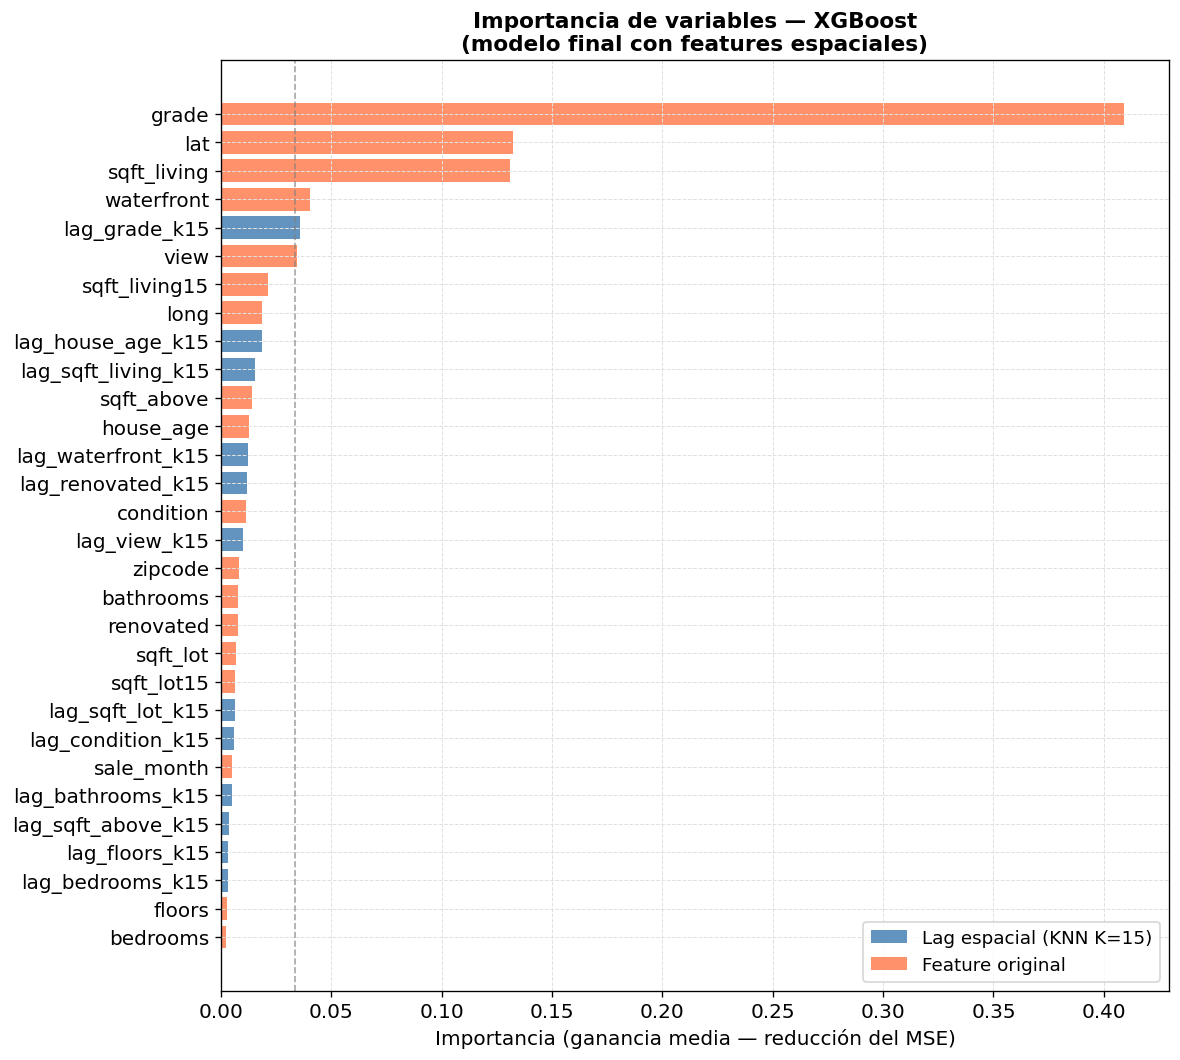


Top 5 features más importantes:
  [orig] grade: 0.4090
  [orig] lat: 0.1321
  [orig] sqft_living: 0.1310
  [orig] waterfront: 0.0404
  [LAG] lag_grade_k15: 0.0358


In [9]:
from matplotlib.patches import Patch

importances = pd.Series(xgb_final.feature_importances_, index=X_train_spatial.columns)
importances = importances.sort_values(ascending=True)

colors = ['steelblue' if c.startswith('lag_') else 'coral' for c in importances.index]

fig, ax = plt.subplots(figsize=(10, 9))
ax.barh(importances.index, importances.values, color=colors, alpha=0.85)

legend_elements = [
    Patch(facecolor='steelblue', alpha=0.85, label='Lag espacial (KNN K=15)'),
    Patch(facecolor='coral',     alpha=0.85, label='Feature original')
]
ax.legend(handles=legend_elements, fontsize=11, loc='lower right')

mean_imp = importances.mean()
ax.axvline(mean_imp, color='gray', linestyle='--', linewidth=1, alpha=0.7,
           label=f'Media = {mean_imp:.3f}')

ax.set_xlabel('Importancia (ganancia media — reducción del MSE)', fontsize=12)
ax.set_title('Importancia de variables — XGBoost\n(modelo final con features espaciales)',
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES + '05_xgb_feature_importance.png')
plt.show()

print('\nTop 5 features más importantes:')
for feat, imp in importances.tail(5)[::-1].items():
    tipo = 'LAG' if feat.startswith('lag_') else 'orig'
    print(f'  [{tipo}] {feat}: {imp:.4f}')

---
## 9. Análisis de residuos

Los residuos son `y_real - ŷ` en escala logarítmica. Un buen modelo debe mostrar:

1. **Histograma**: distribución aproximadamente normal centrada en 0 → sin sesgo sistemático
2. **Scatter real vs predicho**: puntos alineados en la diagonal → sin heterocedasticidad
3. **Mapa geográfico**: residuos distribuidos aleatoriamente en el espacio → sin clusters → Moran's I ≈ 0

> Si en el mapa aparecen **manchas de un mismo color** (clusters de subestimación o sobreestimación),  
> significa que el modelo no captura completamente el efecto de localización, pese a los spatial lags.

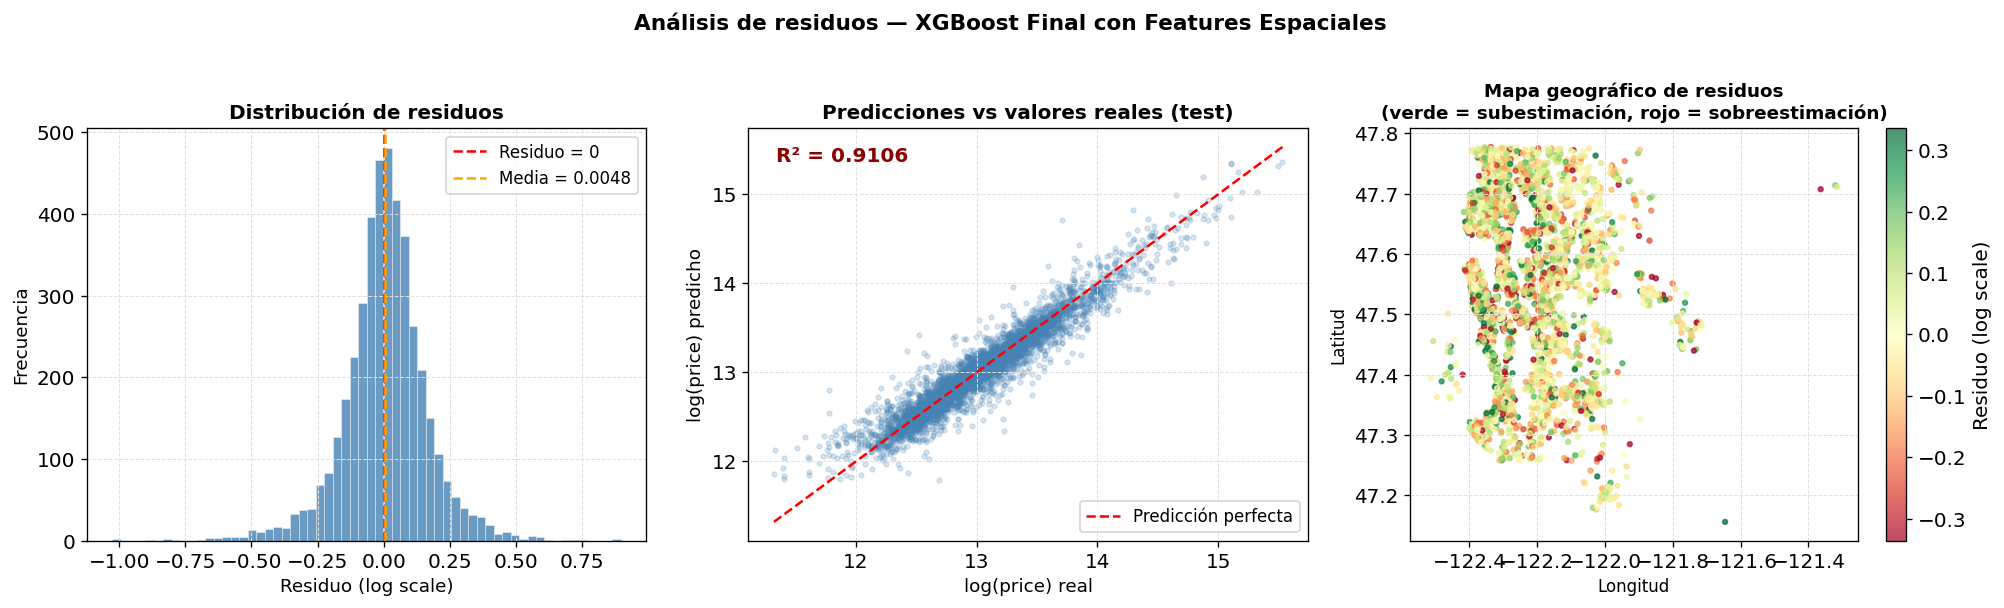

Estadísticas de residuos:
  Media:   0.0048  (idealmente ≈ 0)
  Std:     0.1598
  Máx:     0.8958
  Mín:     -1.0263


In [10]:
residuos = y_test.values - y_pred_final

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Panel 1: Distribución de residuos
axes[0].hist(residuos, bins=60, color='steelblue', alpha=0.8, edgecolor='white', linewidth=0.3)
axes[0].axvline(0, color='red', linewidth=1.5, linestyle='--', label='Residuo = 0')
axes[0].axvline(residuos.mean(), color='orange', linewidth=1.5, linestyle='--',
                label=f'Media = {residuos.mean():.4f}')
axes[0].set_xlabel('Residuo (log scale)', fontsize=11)
axes[0].set_ylabel('Frecuencia', fontsize=11)
axes[0].set_title('Distribución de residuos', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)

# Panel 2: Predicciones vs valores reales
axes[1].scatter(y_test, y_pred_final, alpha=0.2, s=8, color='steelblue')
lims = [min(y_test.min(), y_pred_final.min()), max(y_test.max(), y_pred_final.max())]
axes[1].plot(lims, lims, 'r--', linewidth=1.5, label='Predicción perfecta')
r2_val = r2_score(y_test, y_pred_final)
axes[1].annotate(f'R² = {r2_val:.4f}', xy=(0.05, 0.92), xycoords='axes fraction',
                 fontsize=12, fontweight='bold', color='darkred')
axes[1].set_xlabel('log(price) real', fontsize=11)
axes[1].set_ylabel('log(price) predicho', fontsize=11)
axes[1].set_title('Predicciones vs valores reales (test)', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)

# Panel 3: Mapa geográfico de residuos
sc = axes[2].scatter(
    coords_test[:, 1], coords_test[:, 0],
    c=residuos, cmap='RdYlGn', s=8, alpha=0.7,
    vmin=-np.percentile(np.abs(residuos), 95),
    vmax= np.percentile(np.abs(residuos), 95)
)
plt.colorbar(sc, ax=axes[2], label='Residuo (log scale)')
axes[2].set_title('Mapa geográfico de residuos\n(verde = subestimación, rojo = sobreestimación)',
                  fontsize=11, fontweight='bold')
axes[2].set_xlabel('Longitud', fontsize=10)
axes[2].set_ylabel('Latitud', fontsize=10)

plt.suptitle('Análisis de residuos — XGBoost Final con Features Espaciales',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES + '05_xgb_residuos.png', bbox_inches='tight')
plt.show()

print('Estadísticas de residuos:')
print(f'  Media:   {residuos.mean():.4f}  (idealmente ≈ 0)')
print(f'  Std:     {residuos.std():.4f}')
print(f'  Máx:     {residuos.max():.4f}')
print(f'  Mín:     {residuos.min():.4f}')

---
## 10. Índice de Moran I — Autocorrelación espacial de residuos

El **Índice de Moran I** mide si los residuos del modelo están espacialmente correlacionados:
- **I ≈ 0**: residuos distribuidos aleatoriamente en el espacio → el modelo captura bien la geografía
- **I > 0**: residuos similares se agrupan geográficamente → quedan patrones espaciales sin modelar
- **I < 0**: residuos distintos se agrupan → patrón espacial negativo (raro en precios)

Referencia: el `log(price)` bruto tiene **Moran's I = 0.84** (alta autocorrelación).  
El RF final logró reducirlo a **0.0797** — ¿XGBoost mejora ese resultado?

In [11]:
print("Moran's I de los residuos del modelo XGBoost final:")
moran_xgb = compute_moran_i(residuos, coords_test, k=8)

print(f"\nReferencia: Moran's I de log(price) bruto (EDA) = 0.84")
print(f"Referencia: Moran's I RF final                   = 0.0797")
if moran_xgb['moran_i'] is not None:
    reduccion = (0.84 - moran_xgb['moran_i']) / 0.84 * 100
    print(f"\nReducción de autocorrelación espacial (XGB): {reduccion:.1f}%")

Moran's I de los residuos del modelo XGBoost final:
  Moran's I: 0.0384  (p-valor: 0.0010)

Referencia: Moran's I de log(price) bruto (EDA) = 0.84
Referencia: Moran's I RF final                   = 0.0797

Reducción de autocorrelación espacial (XGB): 95.4%


---
## 11. Guardado de artefactos

Guardamos todos los artefactos necesarios para el notebook de comparación final:

| Fichero | Descripción |
|---------|-------------|
| `outputs/models/xgb_final.joblib` | Modelo serializado para inferencia |
| `outputs/metrics/xgb_final.json` | Métricas + Moran's I + mejores hiperparámetros |
| `data/processed/pred_xgb.csv` | Predicciones del test para la tabla comparativa final |

In [12]:
# Guardar modelo
joblib.dump(xgb_final, MODELS + 'xgb_final.joblib')
print(f'Modelo guardado en: outputs/models/xgb_final.joblib')

# Guardar métricas completas
metrics_final['moran_i_residuos'] = moran_xgb['moran_i']
metrics_final['moran_i_pvalue']   = moran_xgb['p_value']
metrics_final['best_params']      = search.best_params_

save_metrics(metrics_final, 'xgb_final.json')

# Guardar predicciones de test para la comparativa final
pred_df = pd.DataFrame({'y_real': y_test.values, 'y_pred_xgb': y_pred_final})
pred_df.to_csv(PROCESSED + 'pred_xgb.csv', index=False)
print(f'Predicciones guardadas en: data/processed/pred_xgb.csv')

print('\n=== RESUMEN FINAL ===')
print(f'  RMSE (log) : {metrics_final["RMSE_log"]:.4f}')
print(f'  MAE  (log) : {metrics_final["MAE_log"]:.4f}')
print(f'  R²         : {metrics_final["R2"]:.4f}')
print(f'  RMSE (USD) : {metrics_final["RMSE_orig"]:,.0f}')
print(f'  MAPE       : {metrics_final["MAPE_orig"]*100:.2f}%')
if moran_xgb['moran_i'] is not None:
    print(f"  Moran's I  : {moran_xgb['moran_i']:.4f}  (p={moran_xgb['p_value']:.4f})")

Modelo guardado en: outputs/models/xgb_final.joblib
Métricas guardadas en: /Users/jesusdelmoral/Documents/master/TFM/tfm-valoracion-inmobiliaria/notebooks/../src/../outputs/metrics/xgb_final.json
Predicciones guardadas en: data/processed/pred_xgb.csv

=== RESUMEN FINAL ===
  RMSE (log) : 0.1599
  MAE  (log) : 0.1144
  R²         : 0.9106
  RMSE (USD) : 116,015
  MAPE       : 11.60%
  Moran's I  : 0.0384  (p=0.0010)
